<div style="display: flex; justify-content: space-between;">
<div style="text-align: left; display: inline-block;" align="left"><b>Tepper School of Business </b></div>
<div style="text-align: right; display: inline-block;" align="right"><i>Copyright Dennis Epple</i></div>
</div>
<hr>
<div style="display: flex; justify-content: space-between;">
<div style="text-align: left" align="left">Statistical Decision Making (45-752)</div>
</div>

# Notebook 2

## Simple Regression: Estimation Using Diamond Data

In [1]:
# This command installs tprstats from its GitHub repo. You only need to run this command once, when start the notebook.
#!pip install git+https://github.com/dnepple/tprstats-python@colab

# stress test to see if this is a good solution to problem of installing tprstats
try:
    import tprstats
except ImportError as e:
  !pip install git+https://github.com/dnepple/tprstats-python@colab
  import tprstats

  Cloning https://github.com/dnepple/tprstats-python (to revision colab) to /tmp/pip-req-build-q1e_l4kp
  Running command git clone --filter=blob:none --quiet https://github.com/dnepple/tprstats-python /tmp/pip-req-build-q1e_l4kp
  Running command git checkout -b colab --track origin/colab
  Switched to a new branch 'colab'
  Branch 'colab' set up to track remote branch 'colab' from 'origin'.
  Resolved https://github.com/dnepple/tprstats-python to commit d5b7ac1c19bfee3ed707aefeeb1cbc04ba8934ca
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.4 MB/s eta 0:00:00
  Created wheel for tprstats: filename=tprstats-0.1.0-py3-none-any.whl size=11433 sha256=e38399a69178cc4de2bccb588e13689ac49ea560fcd08e774bb7d0755111c884
  Stored in directory: /tmp/pip-ephem-wheel-cache-6ity_pb1/wheels/5d/0e/3a/ef7ae3e58a9bf61b5c91546d764aaf5ac5df485b9ce38295fe
Succ

In [2]:
# import the google drive package
from google.colab import drive
# mount google drive
drive.mount('/content/drive')
# set the working directory to the course folder. SDM is an abbreviation of Statistical Decision Making.
%cd '/content/drive/MyDrive/SDM'

Mounted at /content/drive
/content/drive/MyDrive/SDM


In [ ]:
%precision %.4f
import pandas
from scipy.stats import t
from statsmodels import stats
import matplotlib.pyplot as plt

In [ ]:
 # import Data
Diamonds_17_data = pandas.read_excel("data/Diamonds_17.xlsx")
Water_Conservation_Data=pandas.read_excel("data/Water_Conservation_Data.xlsx")

In [ ]:
# get summary statistics such as min, max, mean, median and sd
Diamonds_17_data.describe()

,Observation,Price,Carat
count,17.000000,17.000000,17.000000
mean,9.000000,3523.117647,0.755882
std,5.049752,247.270066,0.044025
min,1.000000,2998.000000,0.690000
25%,5.000000,3331.000000,0.730000
50%,9.000000,3544.000000,0.760000
75%,13.000000,3642.000000,0.780000
max,17.000000,4085.000000,0.850000


In [ ]:
# Regress Price against Carat and name the result OurReg. This is case sensitive
OurReg = tprstats.model("cs", "Price~Carat", data=Diamonds_17_data)

In [ ]:
OurReg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.588
Model:                            OLS   Adj. R-squared:                  0.560
No. Observations:                  17   F-statistic:                     12.32
Covariance Type:                  HC1   Prob (F-statistic):            0.00316
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    268.7373    927.890      0.290      0.776   -1709.013    2246.488
Carat       4305.4059   1226.850      3.509      0.003    1690.438    6920.374
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

If you want more nicely formatted output with the same information, you can use print() with the name of your regression in parentheses. This is illustrated next.

In [ ]:
# View regression results with robust standard errors and improved formatting.
print(OurReg.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.588
Model:                            OLS   Adj. R-squared:                  0.560
No. Observations:                  17   F-statistic:                     12.32
Covariance Type:                  HC1   Prob (F-statistic):            0.00316
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    268.7373    927.890      0.290      0.776   -1709.013    2246.488
Carat       4305.4059   1226.850      3.509      0.003    1690.438    6920.374

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)


<Axes: xlabel='Carat', ylabel='Price'>

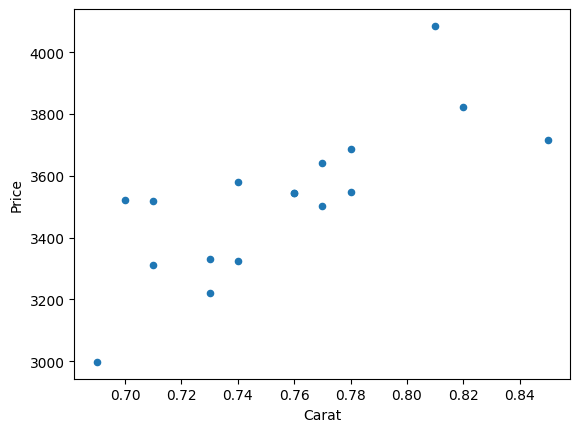

In [ ]:
# Do a Scatterplot of Price versus Carat
Diamond_17_plot = Diamonds_17_data.plot.scatter(x="Carat", y="Price")
Diamond_17_plot

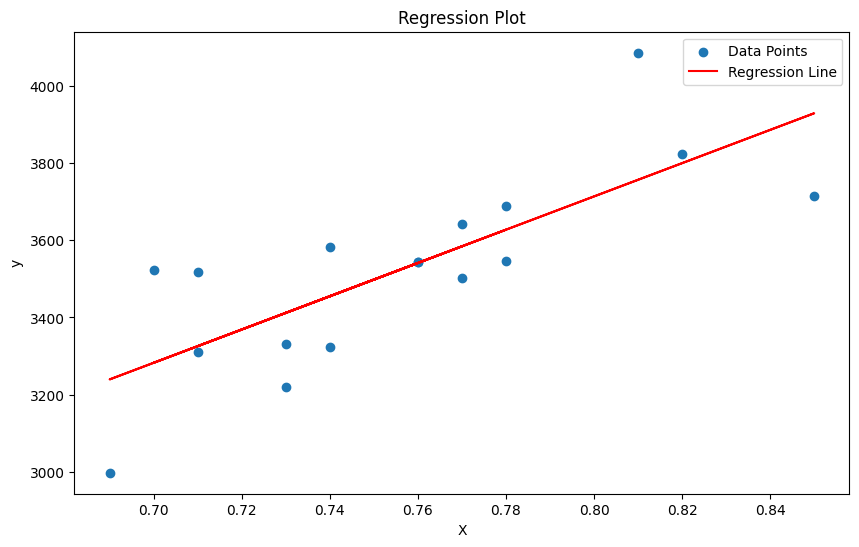

In [ ]:
# Add the regression line
# Calculate predicted values and name the result y_pred
y_pred = OurReg.predict()

# Plotting: This shows you details of how to add a regression line
# I won't ask you to do this on a quiz or exam.
plt.figure(figsize=(10, 6))
# drops the constant term model.X.iloc[: , 1:]
plt.scatter(OurReg.X.iloc[:, 1:], OurReg.y, label="Data Points")
plt.plot(OurReg.X.iloc[:, 1:], y_pred, color="red", label="Regression Line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Regression Plot")
plt.legend()
plt.show()

##   Simple Regression: Hypothesis Testing and Prediction

In [ ]:
# Calculate critical t-value for alpha=.05 and degrees of freedom=15
t.ppf(0.975, 15)

np.float64(2.131449545559323)

In [ ]:
# Calculate two-tailed p-value for calculated t-statistic of 3.51
# with 15 degrees of freedom
2 * t.cdf(-3.51, 15)

np.float64(0.0031580598017810894)

In [ ]:
# Calculate confidence intervals for the coefficients
# Confidence Intervals are included in the summary output
# Ignore warning message.
OurReg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.588
Model:                            OLS   Adj. R-squared:                  0.560
No. Observations:                  17   F-statistic:                     12.32
Covariance Type:                  HC1   Prob (F-statistic):            0.00316
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    268.7373    927.890      0.290      0.776   -1709.013    2246.488
Carat       4305.4059   1226.850      3.509      0.003    1690.438    6920.374
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [ ]:
# Calculate the fitted values from the regression and name them yhat
yhat = OurReg.predict()
# View the fitted values
yhat

array([3411.68361153, 3540.84578907, 3282.52143399, 3325.57549317,
       3626.95390744, 3756.11608498, 3799.17014416, 3928.3323217 ,
       3239.46737481, 3583.89984825, 3626.95390744, 3411.68361153,
       3583.89984825, 3454.73767071, 3540.84578907, 3325.57549317,
       3454.73767071])

In [ ]:
# Calculate the residuals from the regression and name them resid
resid = OurReg.result.resid
# View the residuals
resid

,0
0,-80.683612
1,3.154211
2,239.478566
3,-14.575493
4,61.046093
5,328.883915
6,23.829856
7,-213.332322
8,-241.467375
9,58.100152


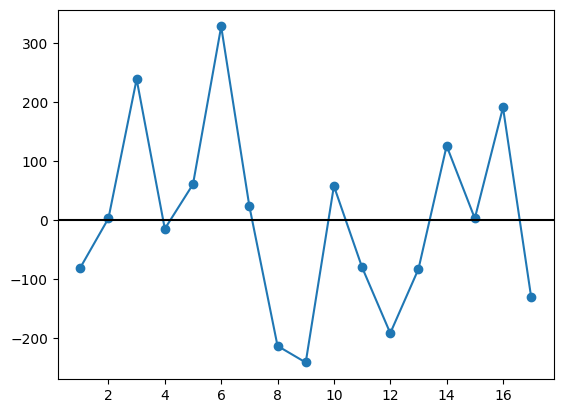

In [ ]:
# Plot the residuals with lines connecting the points
# and with a horizontal line at zero.
plt.scatter(x=Diamonds_17_data["Observation"], y=resid)
plt.plot(Diamonds_17_data["Observation"], resid)
plt.axhline(0, color="black")

In [ ]:
# Put the actual prices, the fitted values, and the residuals
# together in a spreadsheet FitDat
# Extract Price and Carat from Diamonds_17 data file
Price = Diamonds_17_data["Price"]
Carat = Diamonds_17_data["Carat"]
Observation = Diamonds_17_data["Observation"]
# We can now use the Price and Carat variables without
# referencing the data file
FitDat = pandas.DataFrame({"Price": Price, "yhat": yhat, "resid": resid,"Obs":Observation})

# view the spreadsheet
FitDat

,Price,yhat,resid,Obs
0,3331,3411.683612,-80.683612,1
1,3544,3540.845789,3.154211,2
2,3522,3282.521434,239.478566,3
3,3311,3325.575493,-14.575493,4
4,3688,3626.953907,61.046093,5
5,4085,3756.116085,328.883915,6
6,3823,3799.170144,23.829856,7
7,3715,3928.332322,-213.332322,8
8,2998,3239.467375,-241.467375,9
9,3642,3583.899848,58.100152,10


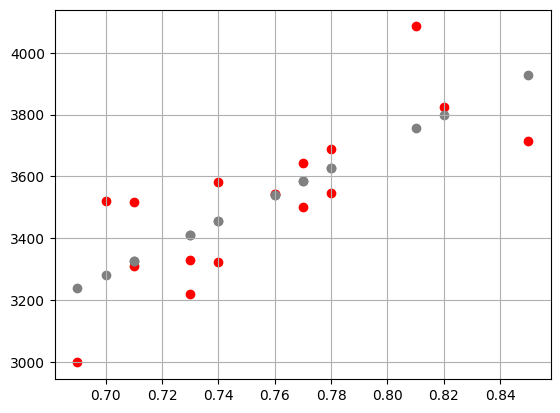

In [ ]:
plt.scatter(Carat, Price, c="red")
plt.scatter(Carat, yhat, c="grey")
plt.grid(True)

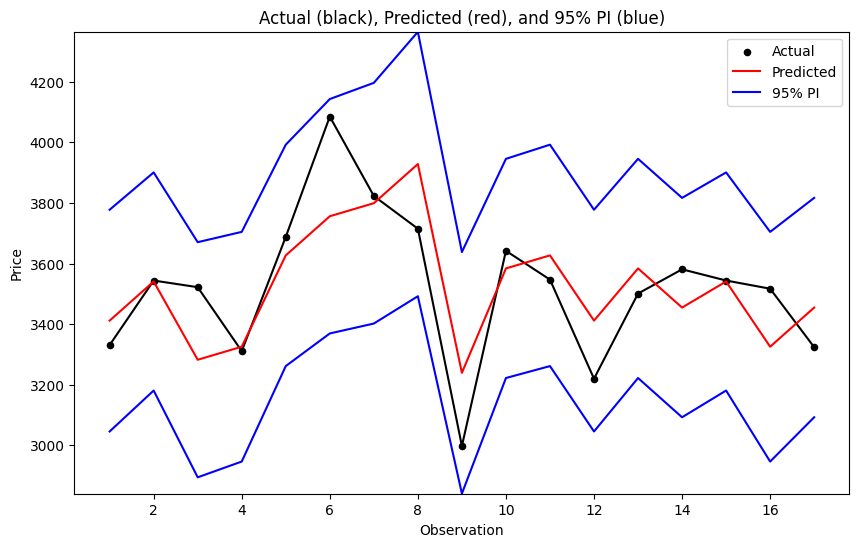

In [ ]:
# Plot actual prices (black dots), fitted values (red),
# and 95% prediction intervals (blue)
# Regression name, OurReg
#plt.figure(figsize=(5,3))
OurReg.plot_actual_fitted()

In [ ]:
# Predicted price and prediction interval
# for a diamond with carat=.75
# Put the new weight of the new diamond in data frame named Xnew
Xnew = pandas.DataFrame({"Carat": [0.75]})
# Calculate and view predicted value and 95% prediction interval
OurReg.prediction_intervals(Xnew)

,Predicted,Lower,Upper
0,3497.79173,3137.804541,3857.778919


In [ ]:
# Predicted price and prediction interval for three diamonds
Xnew = pandas.DataFrame({"Carat": [0.62, 0.74, 0.81]})
OurReg.prediction_intervals(Xnew)

,Predicted,Lower,Upper
0,2938.088961,2432.962197,3443.215724
1,3454.737671,3092.738025,3816.737317
2,3756.116085,3369.343783,4142.888387


In [ ]:
# Put the predicted prices and prediction intervals
# into a spreadsheet named Pred_and_PI
Pred_and_PI = OurReg.prediction_intervals(Xnew)

In [ ]:
# Next command shows how to write results to a csv file.
# Write Pred_and_PI to an Excel csv file named "Our_Predictions.csv"
# This file will be placed in the current directory
Pred_and_PI.to_csv("Our_Predictions.csv")

In [ ]:
# Put the predicted prices and prediction intervals
# into a spreadsheet named Pred_and_PI
Pred_and_PI = OurReg.prediction_intervals(Xnew)

## Slides: Testing Difference in Population Means

In [ ]:
# Calculate p-value for Water Conservation Hypothesis Test
2 * t.cdf(-6.04,83317)

np.float64(1.5476422531805714e-09)

In [ ]:
# Predicted price and prediction interval for three diamonds
Xnew = pandas.DataFrame({"Carat": [0.62, 0.74, 0.81]})
OurReg.prediction_intervals(Xnew)

,Predicted,Lower,Upper
0,2938.088961,2432.962197,3443.215724
1,3454.737671,3092.738025,3816.737317
2,3756.116085,3369.343783,4142.888387


## Regression with Water Conservation Data

In [ ]:
# Import Water_Conservation_Data
 # import Data
Water_Conservation_Data = pandas.read_excel("data/Water_Conservation_Data.xlsx")

The variable named GROUP denotes assignment of each household  

- Households in GROUP 1 received treatment 1.
- Households in GROUP 2 received treatment 2.
- Households in GROUP 3 received treatment 3.
- Households in GROUP 4 were the control group

In [ ]:
# Select the observations in treatment Group 3 and the control group, Group 4
WatDat34 = Water_Conservation_Data.query('GROUP==3|GROUP==4')

In [ ]:
# Run regression to estimate effect of treatment 3 and view the regression output
WatReg34 = tprstats.model("cs", 'SUMMER_07~TREAT3', WatDat34)
WatReg34.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SUMMER_07   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
No. Observations:               83319   F-statistic:                     36.54
Covariance Type:                  HC1   Prob (F-statistic):           1.50e-09
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     36.4725      0.109    333.730      0.000      36.258      36.687
TREAT3        -1.6145      0.267     -6.045      0.000      -2.138      -1.091
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

## Experimental Design: Power and Sample Size

In [ ]:

# statsmodels.stats.power.tt_solve_power¶
# solve for any one parameter of the power of a one sample t-test

# Test of null hypothesis for a single mean: Calculate power with nobs=50
effect_size = 2
stdev = 5
standardized_effect_size = effect_size / stdev
stats.power.tt_solve_power(effect_size= standardized_effect_size, nobs=50, alpha=0.05)


np.float64(0.7917871892678123)

In [ ]:
# Calculate sample size, Automotive Testing Service, test null hypothesis for a
# single mean
effect_size = 2
stdev = 5
standardized_effect_size = effect_size / stdev
stats.power.tt_solve_power(effect_size=standardized_effect_size, alpha=0.05,power=0.85)

58.0671

In the above example, ATS evaluated an SUV with stdev=5.

Below ATS compares compact cars A and B.  
Smaller cars have smaller variance than the SUV.  
Standard deviations are std1=3 and std2=3.  

In [ ]:
# ATS sample size to test difference in population means
# Desired power of the test is .85

tprstats.AB_nobs(diff_means=2, std1= 3, std2=3, alpha=0.05, power = 0.85, ratio=1)

,0
nobs1,41.386145
nobs2,41.386145
nobs_total,82.772291


In [ ]:
# ATS sample size to test difference in means.
# percent_B is set equal to .4 because type B cars are
# more costly to test than type A

tprstats.AB_nobs(diff_means=2, std1= 3, std2=3, alpha=0.05, power = 0.85, ratio=4/6)

,0
nobs1,51.682413
nobs2,34.454942
nobs_total,86.137355


In [ ]:
# Effect Size=3, standard deviations both equal 5, equal sample sizes
tprstats.AB_nobs(diff_means=3, std1=5, std2=5, alpha=0.05, power = 0.9, ratio=1)

,0
nobs1,59.351553
nobs2,59.351553
nobs_total,118.703106


In [ ]:
# Significance of difference between non-opioids and opioids
2*t.cdf(-1.98,238-2)

np.float64(0.048865256977707064)

In [ ]:
from scipy.stats import norm
norm.cdf(-4.788,0,1)

np.float64(8.422582429567219e-07)

In [ ]:
from scipy.stats import norm
1-norm.cdf(-.8683,0,1)

np.float64(0.807384938909162)

In [ ]:
(41.386-42)*50**.5/5

-0.8683271272970764